In [2]:
pip install pandas numpy matplotlib jupyter statsbombpy

Note: you may need to restart the kernel to use updated packages.


In [64]:
import pandas as pd
import numpy as np
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

# pd and np are standard shortcuts used by everyone in the world
# sb is our gateway to all StatsBomb data

In [4]:
# Load all available free competitions
competitions = sb.competitions()

# .head() shows the first 5 rows — always do this first
print(competitions.head())
print("Shape:", competitions.shape)  # (rows, columns)

/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


   competition_id  season_id country_name        competition_name  \
0               9        281      Germany           1. Bundesliga   
1               9         27      Germany           1. Bundesliga   
2            1267        107       Africa  African Cup of Nations   
3              16          4       Europe        Champions League   
4              16          1       Europe        Champions League   

  competition_gender  competition_youth  competition_international  \
0               male              False                      False   
1               male              False                      False   
2               male              False                       True   
3               male              False                      False   
4               male              False                      False   

  season_name               match_updated           match_updated_360  \
0   2023/2024  2024-09-28T20:46:38.893391  2025-07-06T04:26:07.636270   
1   2015/2016  202

In [6]:
# Let's pick La Liga 2015/16 — Messi's legendary season
# competition_id=11, season_id=27

matches = sb.matches(competition_id=11, season_id=27)

print(matches.shape)
print(matches.columns.tolist())  # see all column names

/opt/anaconda3/lib/python3.12/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(380, 22)
['match_id', 'match_date', 'kick_off', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_stage', 'stadium', 'referee', 'home_managers', 'away_managers', 'data_version', 'shot_fidelity_version', 'xy_fidelity_version']


In [32]:
# See all matches clearly
matches[['match_id', 'match_date', 'home_team', 'away_team', 
         'home_score', 'away_score']].head(10)

,match_id,match_date,home_team,away_team,home_score,away_score
0,3825848,2015-09-23,Levante UD,Eibar,2,2
1,3825895,2015-09-23,Las Palmas,Sevilla,2,0
2,3825894,2016-05-01,RC Deportivo La Coruña,Getafe,0,2
3,3825855,2016-05-02,Málaga,Levante UD,3,1
4,3825908,2016-05-15,Espanyol,Eibar,4,2
5,3825883,2016-05-15,Málaga,Las Palmas,4,1
6,3825900,2016-05-15,Sporting Gijón,Villarreal,2,0
7,3825902,2016-05-15,Rayo Vallecano,Levante UD,3,1
8,3825876,2016-05-15,Real Betis,Getafe,2,1
9,3825846,2016-05-14,RC Deportivo La Coruña,Real Madrid,0,2


In [54]:
# Filter only Barcelona matches
barca_matches = matches[
    (matches['home_team'] == 'Barcelona') | 
    (matches['away_team'] == 'Barcelona')
]

barca_matches[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score']]

,match_id,match_date,home_team,away_team,home_score,away_score
172,3825660,2015-11-08,Barcelona,Villarreal,3,0
185,3825637,2015-10-25,Barcelona,Eibar,3,1
288,3825645,2015-10-31,Getafe,Barcelona,0,2
300,3825627,2015-10-17,Barcelona,Rayo Vallecano,5,2
306,3825617,2015-10-03,Sevilla,Barcelona,2,1
347,266498,2016-03-12,Barcelona,Getafe,6,0
348,266986,2016-04-30,Real Betis,Barcelona,0,2
349,267533,2016-04-02,Barcelona,Real Madrid,1,2
350,266310,2016-04-20,RC Deportivo La Coruña,Barcelona,0,8
351,267576,2016-01-30,Barcelona,Atlético Madrid,2,1


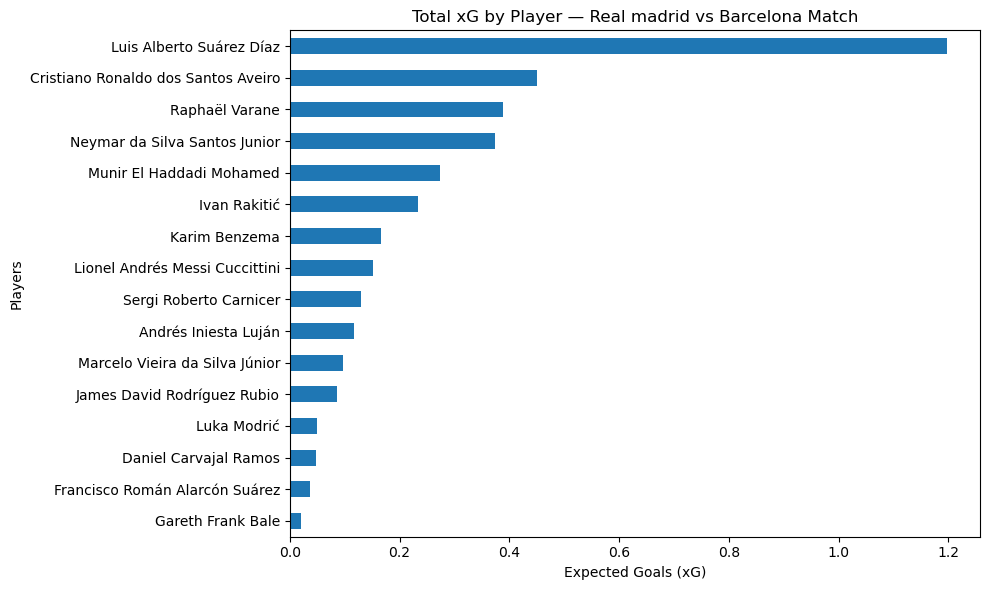

In [66]:
barca_match_id = barca_matches['match_id'].loc[374]

# Load events
events = sb.events(match_id=barca_match_id)

# Filter shots
shots = events[events['type'] == 'Shot']

# Plot xG
shots.groupby('player')['shot_statsbomb_xg'].sum().sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Total xG by Player — Real madrid vs Barcelona Match'
)
import matplotlib.pyplot as plt
plt.xlabel('Expected Goals (xG)')
plt.ylabel('Players')
plt.tight_layout()
plt.show()

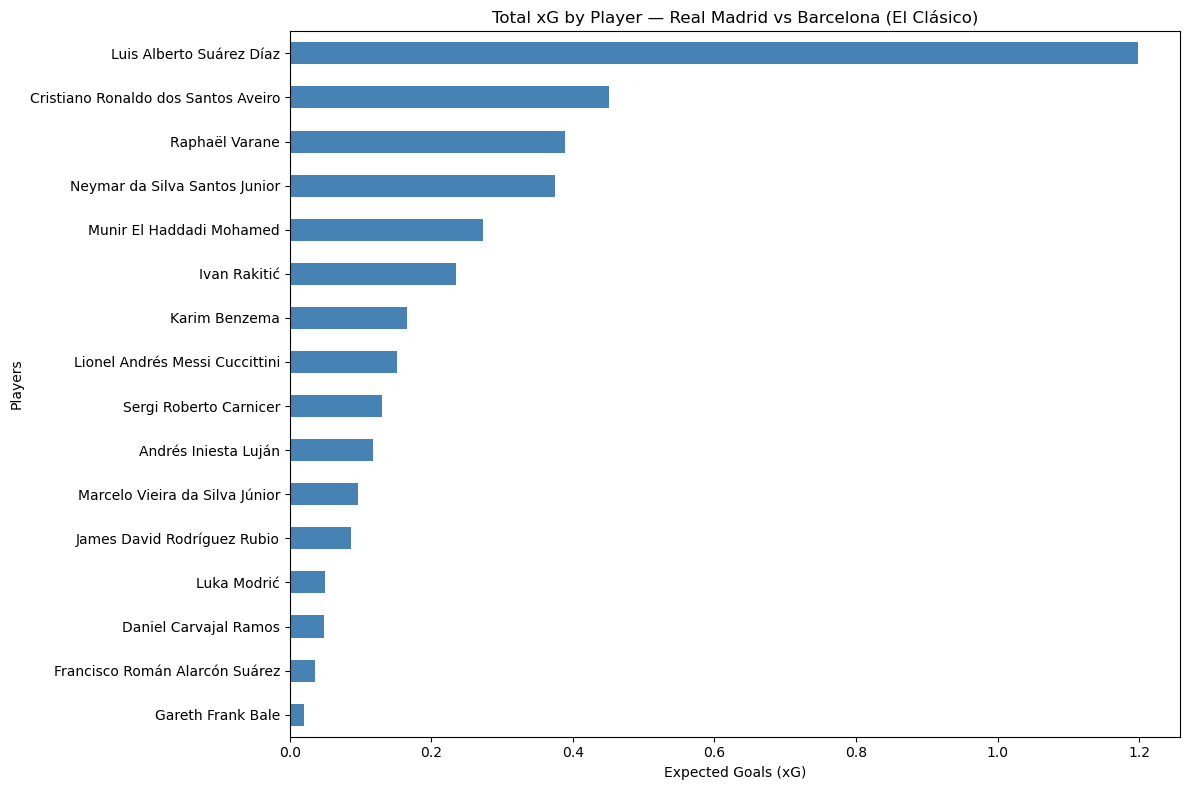

In [68]:
shots.groupby('player')['shot_statsbomb_xg'].sum().sort_values().plot(
    kind='barh',
    figsize=(12, 8),          # slightly bigger
    title='Total xG by Player — Real Madrid vs Barcelona (El Clásico)',
    color='steelblue'
)

plt.xlabel('Expected Goals (xG)')
plt.ylabel('Players')
plt.tight_layout()
plt.savefig('elclasico_xg.png', dpi=150, bbox_inches='tight')  # ← saves clean file
plt.show()